In [1]:
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology import ABC_Testing

In [2]:
all_trace_record, result_summary = ABC_Testing.lcb_trace_evaluation("../Limit History")

In [3]:
summary_for_evaluation = result_summary.drop(columns=['Employed_Algo3','Onlooker_Algo3','expr_name','metric_name','scout_avg','scout_std','train_MCC_LCB_Mean','train_MCC_LCB_std','train_MCC_LCB_sem'])
summary_for_evaluation['L/SN'] = summary_for_evaluation['Trial_Limit']/summary_for_evaluation['Solution_Size']

In [4]:
summary_for_evaluation

,Solution_Size,Trial_Limit,Max_Iteration,val_MCC_LCB_Mean,val_MCC_LCB_std,val_MCC_LCB_sem,train_MCC_trace_floor,val_MCC_trace_floor,L/SN
0,100,100,120,0.549574,0.047330,0.008641,0.656781,0.527280,1.0
1,100,100,250,0.551243,0.044502,0.008125,0.673524,0.530280,1.0
2,100,150,120,0.563554,0.033749,0.006162,0.656783,0.547657,1.5
3,100,150,250,0.552157,0.037243,0.006800,0.673300,0.534614,1.5
4,100,200,120,0.552708,0.043794,0.007996,0.655673,0.532079,2.0
5,100,200,250,0.547535,0.045717,0.008347,0.676928,0.526001,2.0
6,100,50,120,0.551810,0.031135,0.005684,0.653034,0.537144,0.5
7,100,50,250,0.553254,0.042669,0.007790,0.669759,0.533156,0.5
8,10,10,1000,0.553543,0.049435,0.009026,0.657146,0.530257,1.0
9,10,10,120,0.547043,0.047136,0.008606,0.607039,0.524839,1.0


In [5]:
summary_floor = summary_for_evaluation[['L/SN','train_MCC_trace_floor','val_MCC_trace_floor']]
summary_floor

,L/SN,train_MCC_trace_floor,val_MCC_trace_floor
0,1.0,0.656781,0.527280
1,1.0,0.673524,0.530280
2,1.5,0.656783,0.547657
3,1.5,0.673300,0.534614
4,2.0,0.655673,0.532079
5,2.0,0.676928,0.526001
6,0.5,0.653034,0.537144
7,0.5,0.669759,0.533156
8,1.0,0.657146,0.530257
9,1.0,0.607039,0.524839


[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Report Figure\ABC_Limit_Ratio_Convergence_Results__Train_and_Validation_Floor_.png


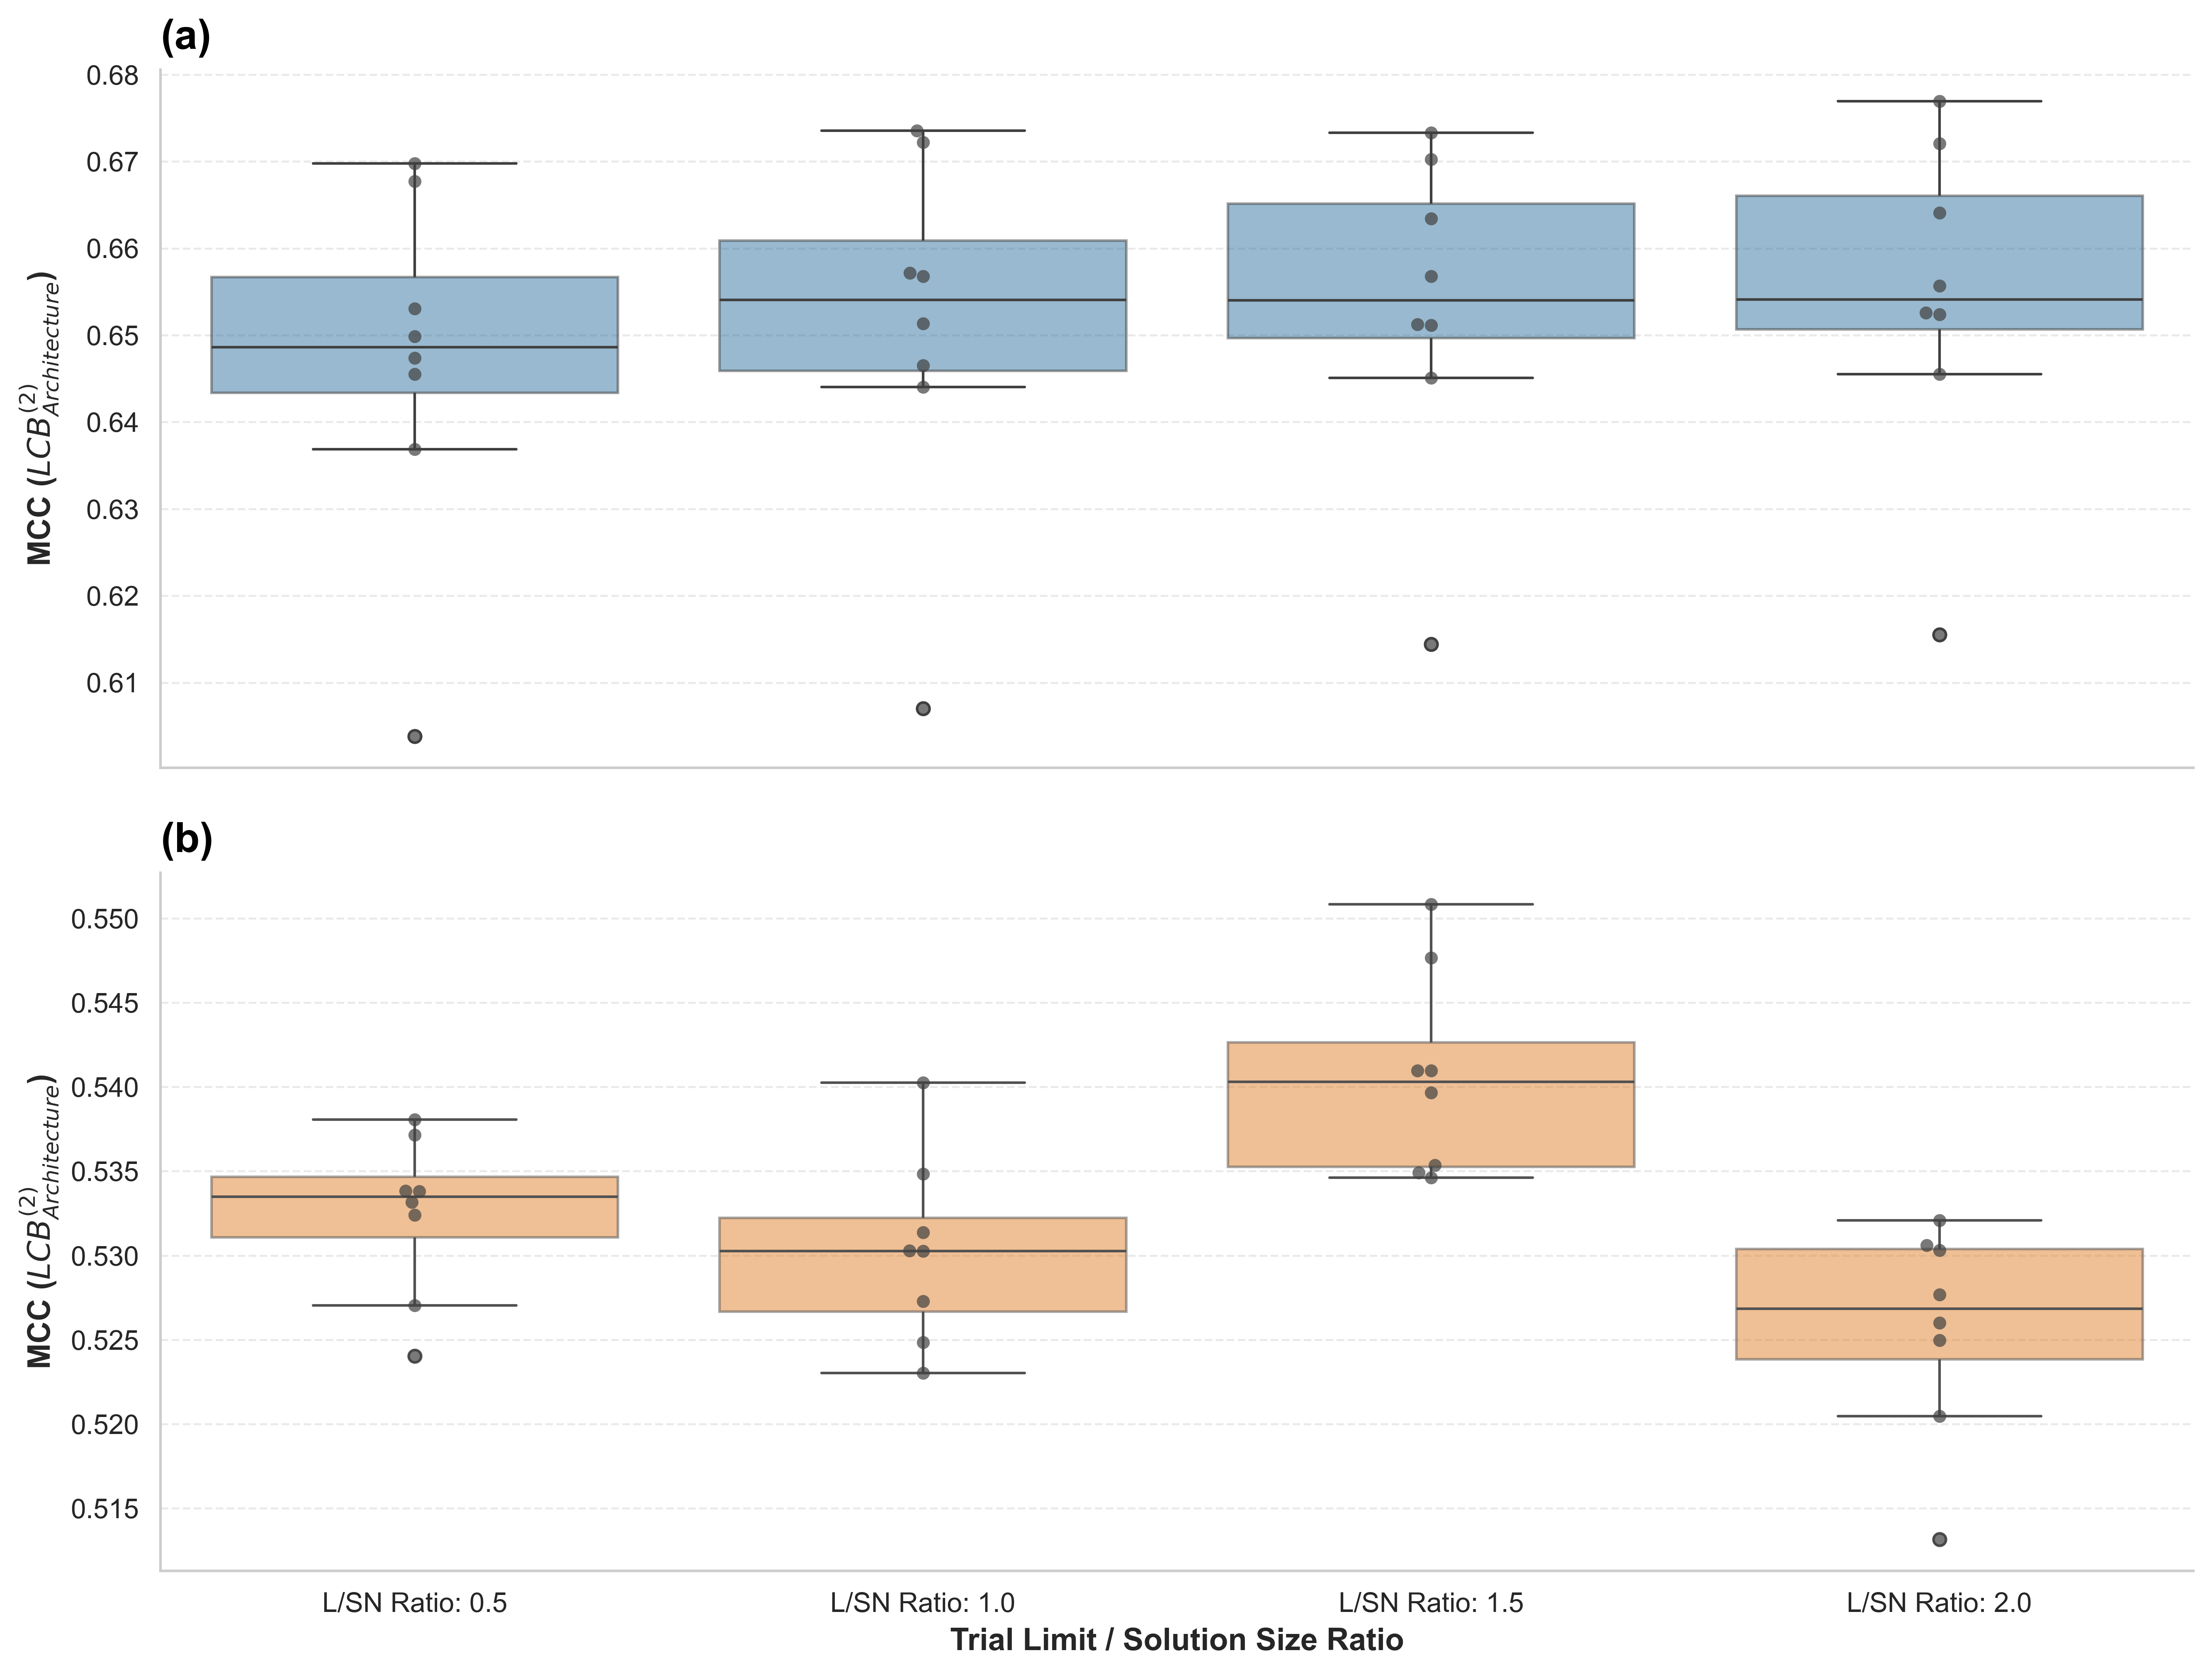

In [6]:
Plotting.plot_ABC_limit_ratio_tracing(summary_floor, is_final_record=True,title_on=False)

In [7]:
df = summary_floor.groupby(['L/SN']).agg(['mean', 'std', 'sem'])
df.columns = ['_'.join(col).strip() for col in df.columns.values]
df = df.reset_index()

df['Triple LCB'] = df['val_MCC_trace_floor_mean'] - GlobalSetting.seed_punish_coe * df['val_MCC_trace_floor_sem']
df

,L/SN,train_MCC_trace_floor_mean,train_MCC_trace_floor_std,train_MCC_trace_floor_sem,val_MCC_trace_floor_mean,val_MCC_trace_floor_std,val_MCC_trace_floor_sem,Triple LCB
0,0.5,0.646745,0.020557,0.007268,0.532433,0.004748,0.001679,0.528102
1,1.0,0.651068,0.020800,0.007354,0.530270,0.005513,0.001949,0.525242
2,1.5,0.653206,0.018483,0.006535,0.540618,0.005990,0.002118,0.535155
3,2.0,0.654335,0.018950,0.006700,0.525660,0.006270,0.002217,0.519940
